# Image Resolution Enhancement - Bicubic Interpolation Method
**Project:** Image Resolution Enhancement Using Optimized Edge-Preserving Interpolation

Method:Bicubic Interpolation Method

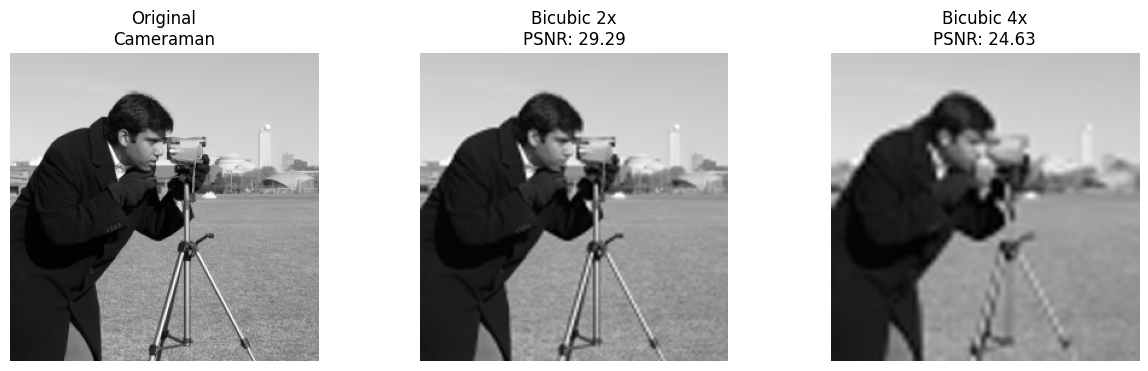

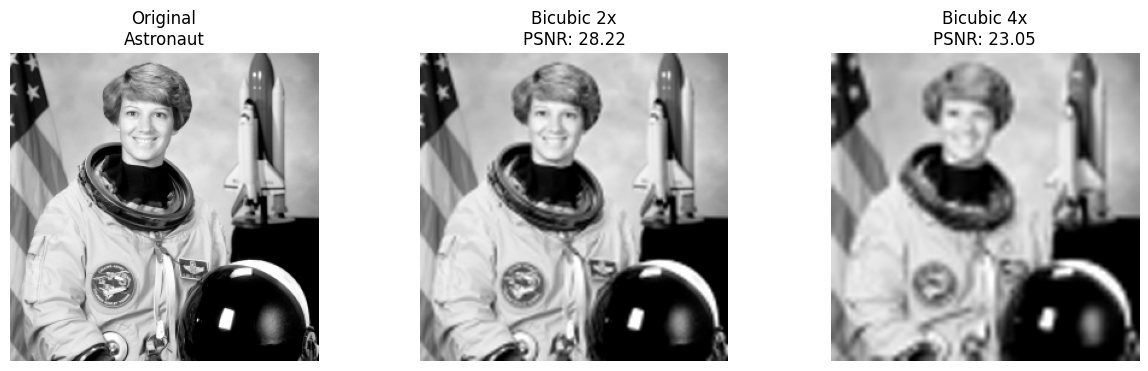

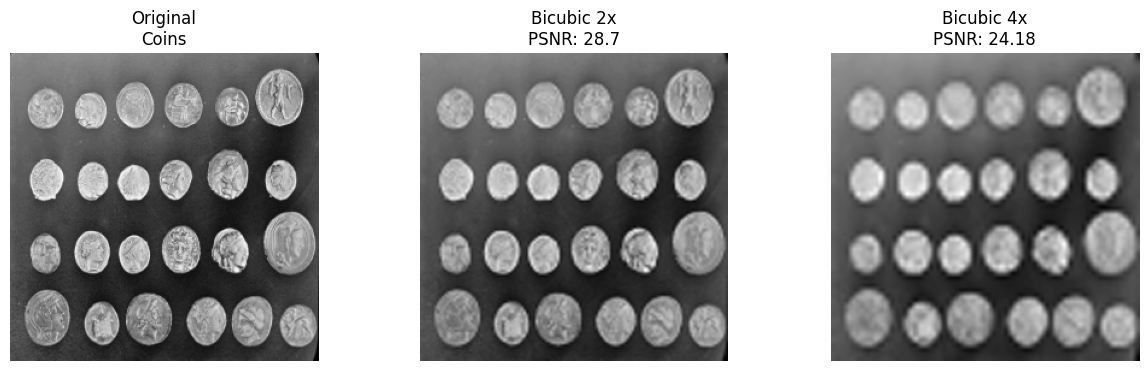

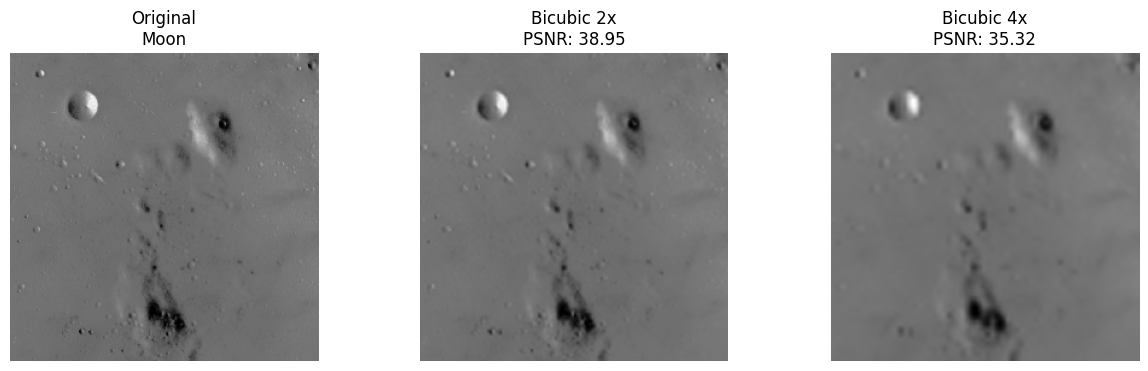

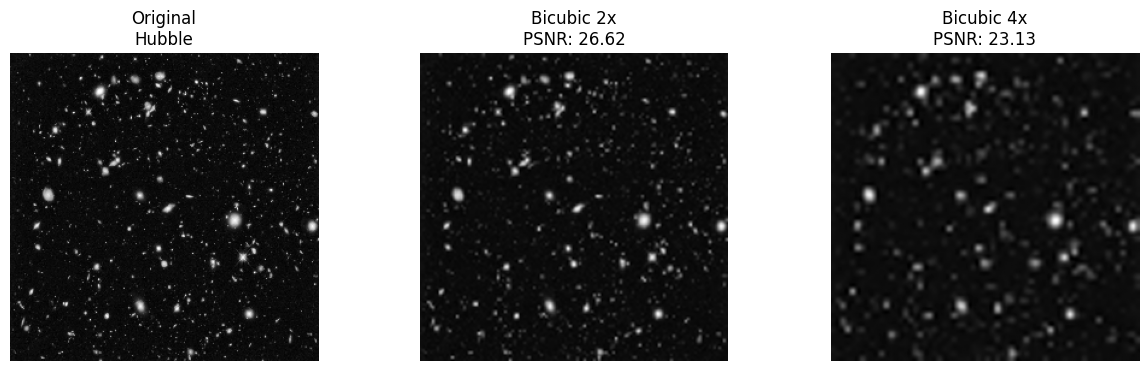

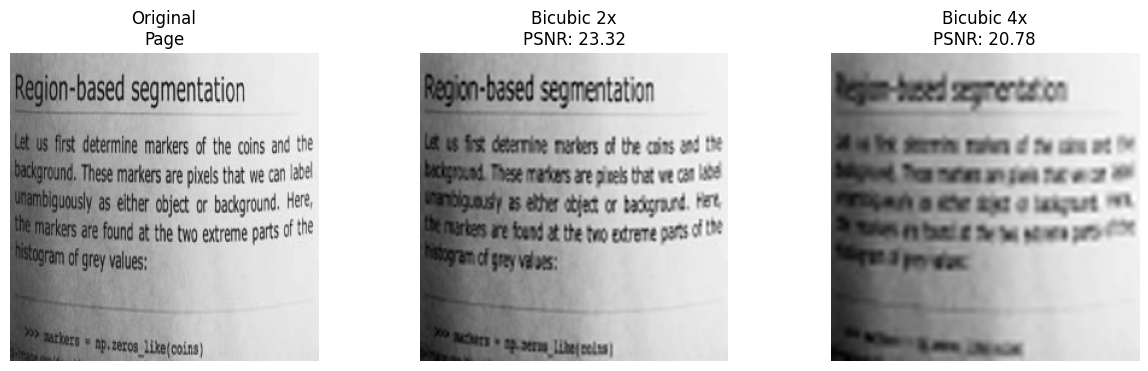

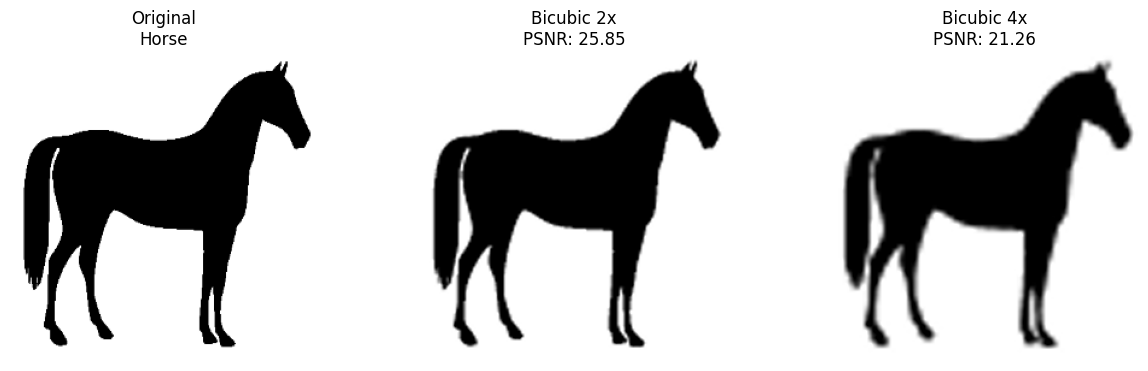

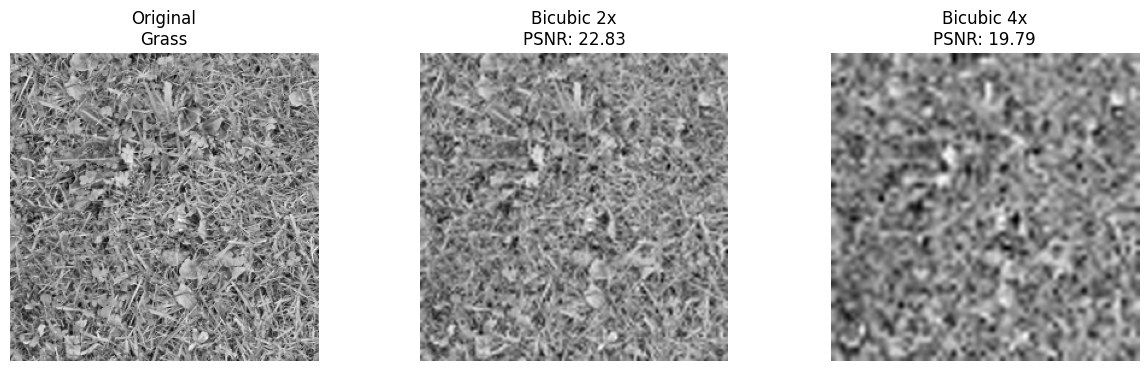

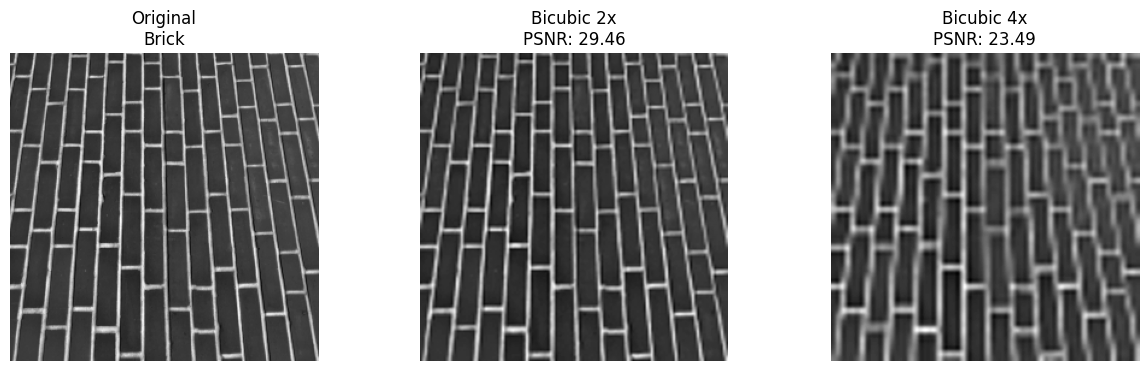

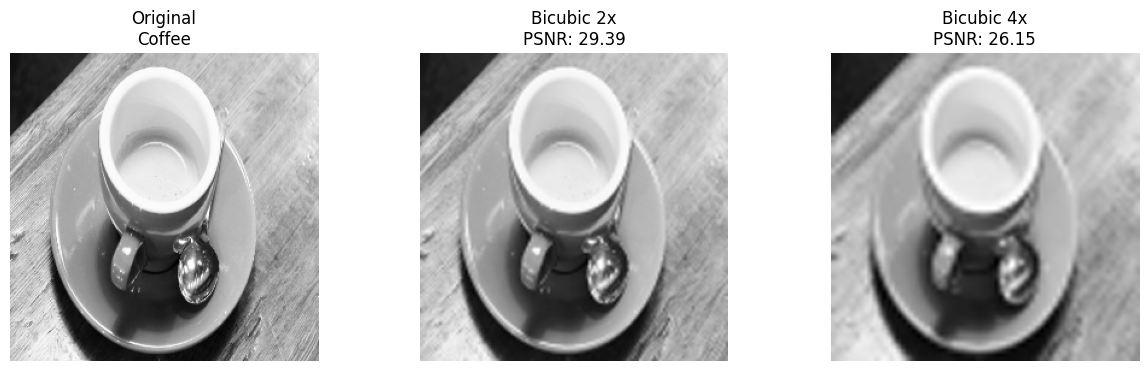

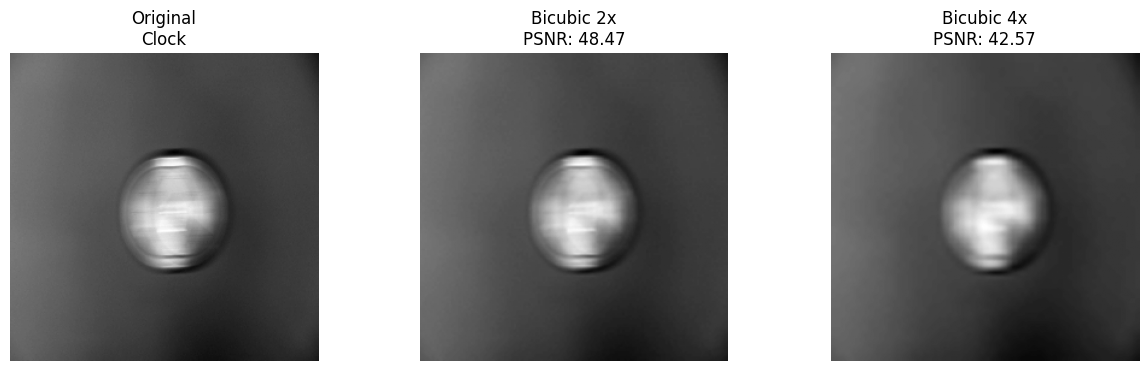

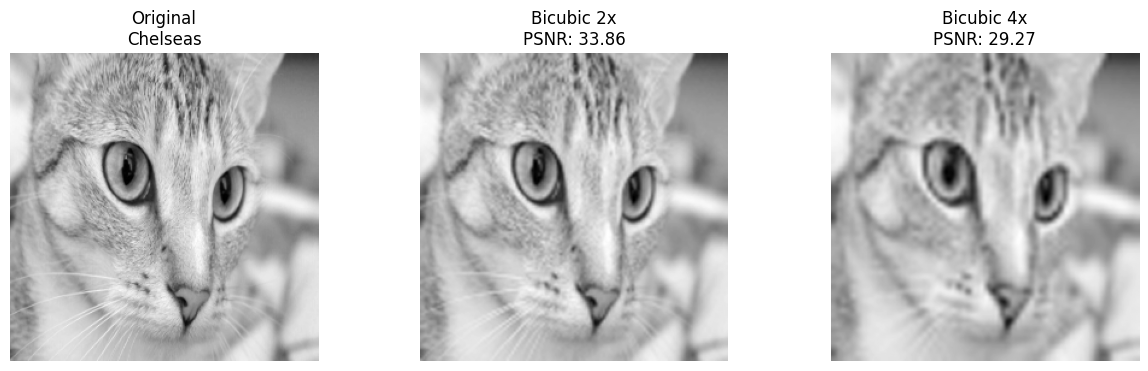

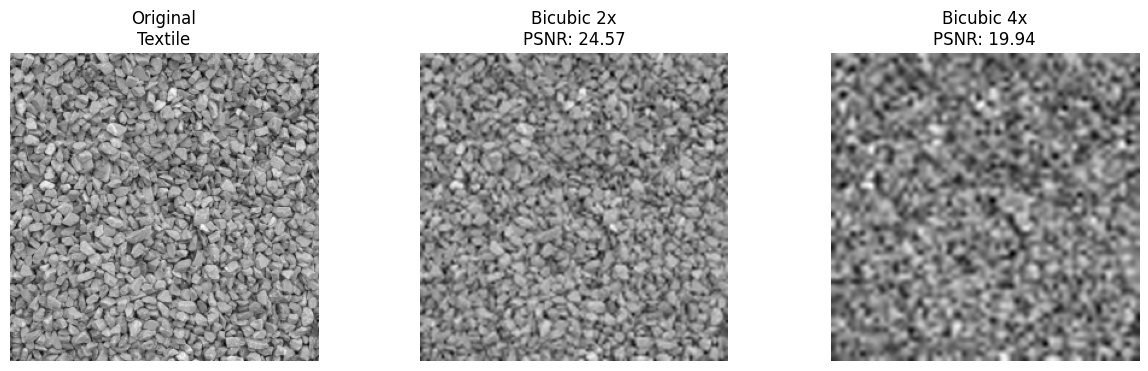

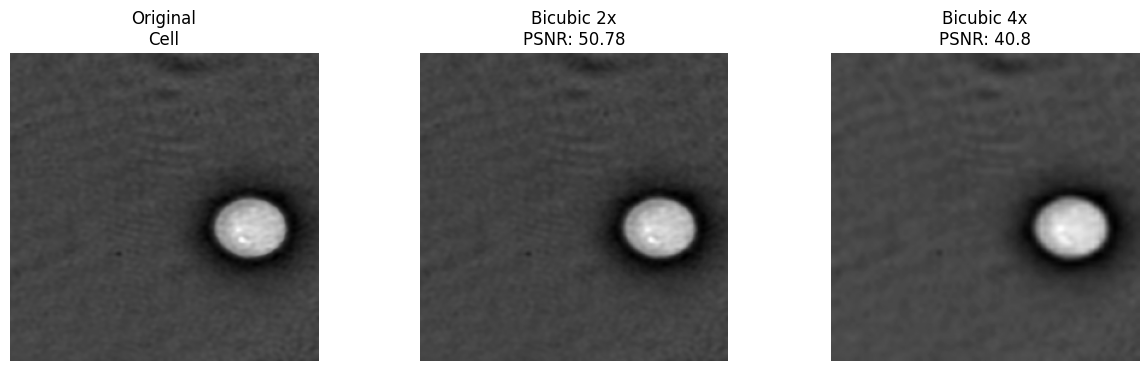

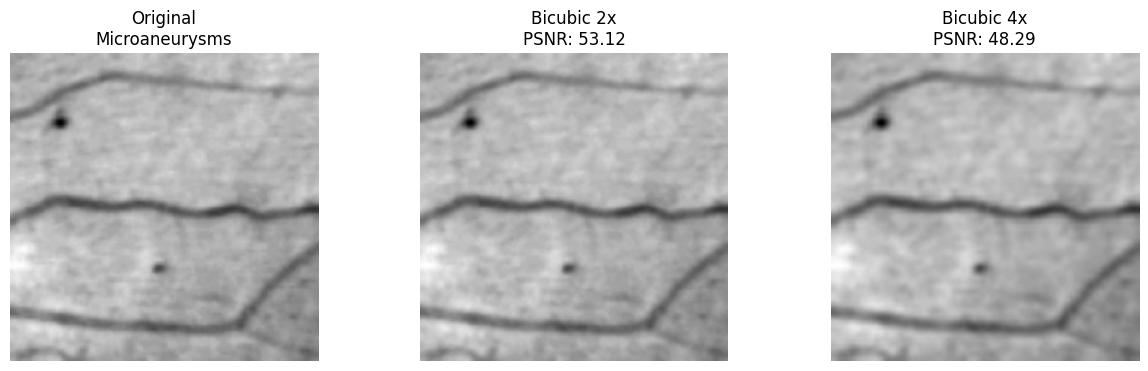

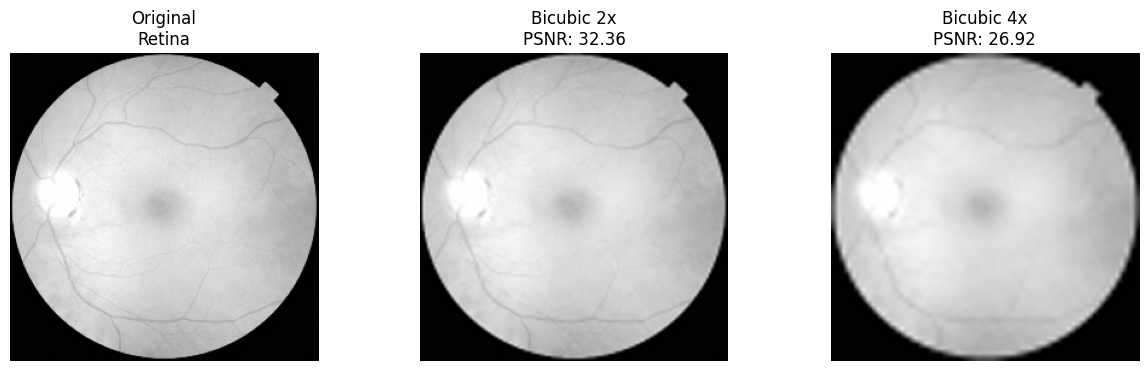

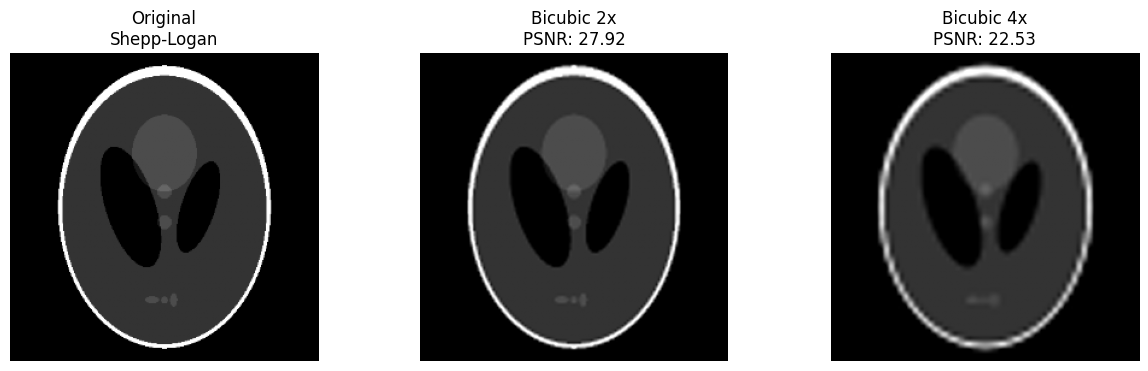


AVERAGE PERFORMANCE ACROSS 17 IMAGES (FULL DATASET)
Scale  PSNR (dB)     SSIM
   x2  32.571176 0.903994
   x4  27.770588 0.764371

DETAILED RESULTS PER IMAGE
         Image Scale  PSNR (dB)   SSIM
     Cameraman    x2      29.29 0.8829
     Cameraman    x4      24.63 0.7439
     Astronaut    x2      28.22 0.9387
     Astronaut    x4      23.05 0.7908
         Coins    x2      28.70 0.8871
         Coins    x4      24.18 0.7140
          Moon    x2      38.95 0.9435
          Moon    x4      35.32 0.8942
        Hubble    x2      26.62 0.7346
        Hubble    x4      23.13 0.5427
          Page    x2      23.32 0.8471
          Page    x4      20.78 0.6722
         Horse    x2      25.85 0.9535
         Horse    x4      21.26 0.8873
         Grass    x2      22.83 0.7428
         Grass    x4      19.79 0.3884
         Brick    x2      29.46 0.9018
         Brick    x4      23.49 0.6249
        Coffee    x2      29.39 0.8716
        Coffee    x4      26.15 0.7445
         Clock    x2  

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import data
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def run_extensive_benchmark_17():
    test_images = {
        "Cameraman": data.camera(),
        "Astronaut": data.astronaut()[:,:,0] if data.astronaut().ndim == 3 else data.astronaut(),
        "Coins": data.coins(),
        "Moon": data.moon(),
        "Hubble": data.hubble_deep_field()[:,:,0] if data.hubble_deep_field().ndim == 3 else data.hubble_deep_field(),
        "Page": data.page(),
        "Horse": data.horse().astype(np.uint8) * 255,
        "Grass": data.grass(),
        "Brick": data.brick(),
        "Coffee": data.coffee()[:,:,0] if data.coffee().ndim == 3 else data.coffee(),
        "Clock": data.clock(),
        "Chelseas": data.chelsea()[:,:,0] if data.chelsea().ndim == 3 else data.chelsea(),
        "Textile": data.gravel(),
        "Cell": data.cell(),
        "Microaneurysms": data.microaneurysms(),
        "Retina": data.retina()[:,:,0] if data.retina().ndim == 3 else data.retina(),
        "Shepp-Logan": data.shepp_logan_phantom()
    }

    scale_factors = [2, 4]
    results = []

    for name, img in test_images.items():
        original = cv2.resize(img, (256, 256))
        if original.dtype != np.uint8:
            original = (original * 255).astype(np.uint8)

        plt.figure(figsize=(15, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(original, cmap='gray')
        plt.title(f"Original\n{name}")
        plt.axis('off')

        for i, scale in enumerate(scale_factors):
            h, w = original.shape
            low_res = cv2.resize(original, (w // scale, h // scale), interpolation=cv2.INTER_AREA)
            bicubic = cv2.resize(low_res, (256, 256), interpolation=cv2.INTER_CUBIC)

            p_val = psnr(original, bicubic)
            s_val = ssim(original, bicubic)

            results.append({
                "Image": name,
                "Scale": f"x{scale}",
                "PSNR (dB)": round(p_val, 2),
                "SSIM": round(s_val, 4)
            })

            plt.subplot(1, 3, i + 2)
            plt.imshow(bicubic, cmap='gray')
            plt.title(f"Bicubic {scale}x\nPSNR: {round(p_val, 2)}")
            plt.axis('off')

        plt.show()

    df = pd.DataFrame(results)

    print("\n" + "="*60)
    print("AVERAGE PERFORMANCE ACROSS 17 IMAGES (FULL DATASET)")
    print("="*60)
    print(df.groupby('Scale')[['PSNR (dB)', 'SSIM']].mean().reset_index().to_string(index=False))

    print("\n" + "="*60)
    print("DETAILED RESULTS PER IMAGE")
    print("="*60)
    print(df.to_string(index=False))

run_extensive_benchmark_17()